# Guaranteed Hedge -- Optimization Formulation (No Fitted Parameters)

Replaces the coverage/moneyness/DTE sweep entirely. No train/test split, because nothing
here is estimated from history -- every decision below is a small constrained optimization
solved using only the option chain observable *on that day*.

**Tier 1 (mathematically guaranteed):** short $n$ shares of TSLL + long $n/100$ TSLL calls,
share-matched (not delta-matched). For strike $K$, premium $C$: worst-case loss from here
forward, for ANY future price, is exactly $K - S_0 + C$ (derived via payoff algebra + the
no-arbitrage floor "option price >= intrinsic value" -- true at every point in time, not
just at expiry). This requires the option to be on TSLL itself; it does NOT depend on the
option "tracking" the stock, only on that one no-arbitrage inequality.

**The optimization, solved fresh at every re-hedge event:**

$$\min_{(K,T) \in \mathcal{C}_t} C(K,T) \quad \text{s.t.} \quad K - S_0 + C(K,T) \le L \cdot S_0$$

where $\mathcal{C}_t$ = TSLL calls actually listed and liquid today, $L$ = PM's loss
tolerance (10%). Cheapest contract that keeps the guarantee inside budget wins.

**Re-hedge events (never a calendar):**
1. Forced: held contract is within `MIN_DTE_BUFFER` days of expiry (mechanical necessity,
   not a tuned threshold -- just enough runway to execute the exit).
2. Restoration: currently on Tier 2 (fallback) and a Tier-1-feasible contract exists today.

**Tier 2 (fallback, NOT guaranteed):** used only when no TSLL call satisfies the Tier-1
constraint at any strike -- this is "the math doesn't suit" from the chat. Falls back to
the existing BS-delta/coverage-ratio sizing on TSLA calls (more liquid, cheaper, but its
protection depends on TSLL actually tracking ~2x TSLA, a model assumption, not a contract).

The guarantee is **rolling**: renewed relative to TSLL's spot at the moment of each
re-hedge, not the strategy's original inception price -- "you will not lose more than 10%
from here forward, until the next event" rather than a single lifetime bound.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsla_underlying, load_tsll, load_tsla_calls, load_tsll_calls
from options_selection import select_contract, bs_delta
from metrics import summarize
from cba_backtest import R_RF, TSLL_LEVER

%matplotlib inline

VOL_WINDOW = 21
LOSS_TOLERANCE = 0.10       # PM's mandate: never lose more than 10%, inclusive of hedge cost
MIN_DTE_BUFFER = 5          # mechanical -- just enough runway to exit, not a tuned parameter
MAX_DTE_SEARCH = 400        # search window for available TSLL contracts, not a fitted target
MIN_DTE_SEARCH = 60         # floor on tenor -- without this the cheapest-premium objective
                            # keeps picking near-dated contracts, forcing near-constant
                            # turnover; this is a sanity floor, not a fitted target
TSLA_COST_PCT = 0.01        # transaction-cost assumption, matches grid_search.py's "base" scenario


In [2]:
tsll = load_tsll()
tsll_spot_full = tsll.set_index("Date")["Close"]

tsla_spot_full = load_tsla_underlying().set_index("Date")["Close"].reindex(tsll_spot_full.index).ffill()
tsla_sigma_full = (tsla_spot_full.pct_change().rolling(VOL_WINDOW).std() * (252 ** 0.5)).ffill().bfill()
tsll_sigma_full = (tsll_spot_full.pct_change().rolling(VOL_WINDOW).std() * (252 ** 0.5)).ffill().bfill()

tsll_calls = load_tsll_calls()
tsla_calls = load_tsla_calls()
tsla_lookup = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()
tsla_vol_lookup = tsla_calls.set_index(["raw_id", "date"])["px_volume"].to_dict()
tsll_lookup = tsll_calls.set_index(["raw_id", "date"])["px_last"].to_dict()
tsll_vol_lookup = tsll_calls.set_index(["raw_id", "date"])["px_volume"].to_dict()

dates = tsll_spot_full.index
print(f"{len(dates):,} trading days, {dates.min().date()} -> {dates.max().date()}")
print(f"TSLL calls: {len(tsll_calls):,} rows, TSLA calls: {len(tsla_calls):,} rows")


963 trading days, 2022-08-09 -> 2026-06-10
TSLL calls: 46,867 rows, TSLA calls: 532,258 rows


## Tier 1 optimizer: cheapest TSLL call that keeps drawdown-from-peak inside budget

Constraint is now anchored to the running high-water mark, not the strategy's original
capital or a per-cycle reset: the position must never let equity fall more than
`loss_tolerance` below the **peak equity ever reached**. "OK to give back profits, never
breach the limit" -- profits raise the bar (a new peak requires re-checking whether the
held/candidate position still protects against a deeper floor), losses that stay above the
last peak's floor require no action at all.

For a candidate contract $(K, C)$: worst-case future equity (if price keeps rising past
$K$, forever) is $V_t + n_{shares}\cdot(S_t - K - C)$. Feasible iff that floor is still
$\ge (1-L)\cdot P_t$, where $P_t$ is the peak-to-date and $V_t$ is today's mark.

In [3]:
def find_cheapest_guaranteed_call(calls_df, spot_val, date, loss_tolerance,
                                  n_shares, peak_equity, current_equity,
                                  max_dte=MAX_DTE_SEARCH, min_dte=MIN_DTE_SEARCH):
    day = calls_df[calls_df["date"] == date]
    if day.empty:
        return None
    dte = (day["expiry"] - date).dt.days
    mask = (
        (dte >= min_dte) & (dte <= max_dte)
        & day["px_last"].notna() & (day["px_last"] > 0)
        & day["px_volume"].notna() & (day["px_volume"] > 0)
    )
    candidates = day[mask].copy()
    if candidates.empty:
        return None
    candidates["worst_case_equity"] = (
        current_equity + n_shares * (spot_val - candidates["strike"] - candidates["px_last"])
    )
    floor = (1 - loss_tolerance) * peak_equity
    feasible = candidates[candidates["worst_case_equity"] >= floor]
    if feasible.empty:
        return None
    return feasible.loc[feasible["px_last"].idxmin()]


def held_tier1_still_sufficient(position, spot_val, n_shares, loss_tolerance, peak_equity, current_equity):
    """Check an ALREADY-HELD Tier-1 contract against a (possibly just-updated) peak --
    no new premium to pay, so the floor uses the strike alone, not strike+premium."""
    worst_case_equity = current_equity + n_shares * (spot_val - position["strike"])
    return worst_case_equity >= (1 - loss_tolerance) * peak_equity


## Tier 2 fallback: existing BS-delta / coverage-ratio sizing on TSLA calls

Not guaranteed -- protection depends on TSLL actually tracking ~2x TSLA. Reused from the
earlier CBA/convexity-protection work rather than re-derived.

In [4]:
def tier2_position(spot_val, sigma_val, notional, date, moneyness_bucket="ATM", target_dte=180, max_dte=200):
    row = select_contract(tsla_calls, tsla_spot_full, date, moneyness_bucket, target_dte, max_dte=max_dte)
    if row is None:
        return None
    entry = float(row["px_last"])
    T = max((row["expiry"] - date).days / 365.25, 1 / 365)
    delta = bs_delta(float(spot_val), float(row["strike"]), T, R_RF, sigma_val)
    n = TSLL_LEVER * notional / (max(delta, 0.01) * 100 * float(spot_val))
    return {"tier": 2, "raw_id": row["raw_id"], "strike": float(row["strike"]), "expiry": row["expiry"],
            "n": n, "price": entry, "entry_price": entry,
            "entry_volume": float(row["px_volume"]) if pd.notna(row.get("px_volume")) else 1.0}


## Event-driven simulation -- forced-expiry, tier-restoration, AND new-peak re-check

Three triggers now, still no calendar:
1. Forced: held contract within `MIN_DTE_BUFFER` days of expiry.
2. Restoration: on Tier 2, and a Tier-1-feasible contract exists today.
3. **New peak**: equity just set an all-time high, and the currently-held Tier-1 contract
   no longer protects against a further `LOSS_TOLERANCE` drawdown from that new peak --
   profits are allowed to be given back, but the floor itself is never allowed to slip.

Short leg: fixed $1 notional in TSLL shares, established once, never resized -- same as
before, so contract count per Tier-1 cycle is always `n_shares/100`, no share-count drift.

In [5]:
def cost_of(premium_value, date, volume, sigma_series, sigma_baseline, volume_baseline, cost_pct):
    sig_now = float(sigma_series.loc[date]) if date in sigma_series.index else sigma_baseline
    vol_mult = np.clip(sig_now / sigma_baseline, 0.5, 2.5)
    liq_mult = np.clip(volume_baseline / max(volume, 1.0), 0.5, 3.0)
    return premium_value * cost_pct * vol_mult * liq_mult

def simulate_guaranteed_hedge(dates, notional=1.0):
    S_incep = float(tsll_spot_full.loc[dates[0]])
    n_shares = notional / S_incep  # fixed forever -- buy & hold short leg

    sigma_baseline_tsla = float(tsla_sigma_full.median())
    sigma_baseline_tsll = float(tsll_sigma_full.median())
    volume_baseline_tsla = float(tsla_calls["px_volume"].median())
    volume_baseline_tsll = float(tsll_calls["px_volume"].median()) if len(tsll_calls) else 1.0

    base_equity = notional - n_shares * (tsll_spot_full.loc[dates] - S_incep)
    equity = pd.Series(index=dates, dtype=float)
    tier_track = pd.Series(index=dates, dtype=float)
    guaranteed_bound_track = pd.Series(index=dates, dtype=float)

    position = None
    option_pnl = 0.0
    peak_equity = notional
    stats = {"forced_rolls": 0, "tier1_restorations": 0, "tier2_falls_back": 0,
             "peak_rechecks": 0, "days_tier1": 0, "days_tier2": 0, "days_unhedged": 0}

    def mtm_tsla(pos, date):
        if date > pos["expiry"]:
            return max(float(tsla_spot_full.loc[date]) - pos["strike"], 0.0)
        px = tsla_lookup.get((pos["raw_id"], date))
        return float(px) if px is not None and not pd.isna(px) else pos["price"]

    def mtm_tsll(pos, date):
        if date > pos["expiry"]:
            return max(float(tsll_spot_full.loc[date]) - pos["strike"], 0.0)
        px = tsll_lookup.get((pos["raw_id"], date))
        return float(px) if px is not None and not pd.isna(px) else pos["price"]

    def open_tier1(row, date):
        entry_volume = float(row["px_volume"]) if pd.notna(row.get("px_volume")) else volume_baseline_tsll
        return {"tier": 1, "raw_id": row["raw_id"], "strike": float(row["strike"]), "expiry": row["expiry"],
                "n": n_shares / 100, "price": float(row["px_last"]), "entry_price": float(row["px_last"]),
                "entry_volume": entry_volume, "cycle_S0": float(tsll_spot_full.loc[date])}

    def close_cost(pos, px, date):
        if pos["tier"] == 1:
            return cost_of(pos["n"] * 100 * px, date, pos["entry_volume"],
                            tsll_sigma_full, sigma_baseline_tsll, volume_baseline_tsll, TSLA_COST_PCT)
        return cost_of(pos["n"] * 100 * px, date, pos["entry_volume"],
                        tsla_sigma_full, sigma_baseline_tsla, volume_baseline_tsla, TSLA_COST_PCT)

    def open_cost(pos, date):
        if pos["tier"] == 1:
            return cost_of(pos["n"] * 100 * pos["price"], date, pos["entry_volume"],
                            tsll_sigma_full, sigma_baseline_tsll, volume_baseline_tsll, TSLA_COST_PCT)
        return cost_of(pos["n"] * 100 * pos["price"], date, pos["entry_volume"],
                        tsla_sigma_full, sigma_baseline_tsla, volume_baseline_tsla, TSLA_COST_PCT)

    def establish_new_position(d, peak_eq, cur_eq):
        spot_now = float(tsll_spot_full.loc[d])
        row1 = find_cheapest_guaranteed_call(tsll_calls, spot_now, d, LOSS_TOLERANCE,
                                             n_shares, peak_eq, cur_eq)
        if row1 is not None:
            return open_tier1(row1, d), True
        sig_now = float(tsla_sigma_full.loc[d]) if d in tsla_sigma_full.index else 0.5
        pos2 = tier2_position(tsla_spot_full.loc[d], sig_now, notional, d)
        return pos2, False

    for d in dates:
        # 1. Mark existing position to today, update running P&L
        if position is not None:
            px = mtm_tsll(position, d) if position["tier"] == 1 else mtm_tsla(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        current_equity = base_equity.loc[d] + option_pnl
        new_peak = current_equity > peak_equity
        if new_peak:
            peak_equity = current_equity

        # 2. Determine triggers
        held_dte = (position["expiry"] - d).days if position is not None else -1
        forced = position is not None and held_dte < MIN_DTE_BUFFER
        peak_insufficient = False
        if position is not None and position["tier"] == 1 and not forced:
            spot_now = float(tsll_spot_full.loc[d])
            if not held_tier1_still_sufficient(position, spot_now, n_shares, LOSS_TOLERANCE,
                                                peak_equity, current_equity):
                peak_insufficient = True

        need_new = position is None or forced or peak_insufficient

        if need_new:
            if position is not None:
                cc = close_cost(position, position["price"], d)
                option_pnl -= cc
                current_equity -= cc
                if forced:
                    stats["forced_rolls"] += 1
                elif peak_insufficient:
                    stats["peak_rechecks"] += 1
                position = None

            new_pos, is_tier1 = establish_new_position(d, peak_equity, current_equity)
            position = new_pos
            if position is not None:
                oc = open_cost(position, d)
                option_pnl -= oc
                if not is_tier1:
                    stats["tier2_falls_back"] += 1
        elif position is not None and position["tier"] == 2:
            spot_now = float(tsll_spot_full.loc[d])
            row1 = find_cheapest_guaranteed_call(tsll_calls, spot_now, d, LOSS_TOLERANCE,
                                                 n_shares, peak_equity, current_equity)
            if row1 is not None:
                cc = close_cost(position, position["price"], d)
                option_pnl -= cc
                new_pos = open_tier1(row1, d)
                oc = open_cost(new_pos, d)
                option_pnl -= oc
                position = new_pos
                stats["tier1_restorations"] += 1

        equity.loc[d] = base_equity.loc[d] + option_pnl
        if position is None:
            tier_track.loc[d] = 0
            guaranteed_bound_track.loc[d] = np.nan
            stats["days_unhedged"] += 1
        elif position["tier"] == 1:
            tier_track.loc[d] = 1
            guaranteed_bound_track.loc[d] = (position["strike"] - position["cycle_S0"] + position["entry_price"]) / position["cycle_S0"]
            stats["days_tier1"] += 1
        else:
            tier_track.loc[d] = 2
            guaranteed_bound_track.loc[d] = np.nan
            stats["days_tier2"] += 1

    return equity, tier_track, guaranteed_bound_track, stats


## Run over the full available history -- no train/test split, nothing here is fitted

In [6]:
equity, tier_track, guaranteed_bound, stats = simulate_guaranteed_hedge(dates)

print(stats)
print(f"\nTrough: {equity.min():.4f} on {equity.idxmin().date()}")
print(f"Final equity: {equity.iloc[-1]:.4f}")
n_days = len(dates)
n_tier1 = stats["days_tier1"]
n_tier2 = stats["days_tier2"]
print(f"Days on Tier 1 (guaranteed): {n_tier1} / {n_days} ({n_tier1 / n_days:.1%})")
print(f"Days on Tier 2 (best-effort): {n_tier2} / {n_days} ({n_tier2 / n_days:.1%})")


{'forced_rolls': 9, 'tier1_restorations': 11, 'tier2_falls_back': 12, 'peak_rechecks': 5, 'days_tier1': 700, 'days_tier2': 263, 'days_unhedged': 0}

Trough: 0.8622 on 2024-04-22
Final equity: 1.4312
Days on Tier 1 (guaranteed): 700 / 963 (72.7%)
Days on Tier 2 (best-effort): 263 / 963 (27.3%)


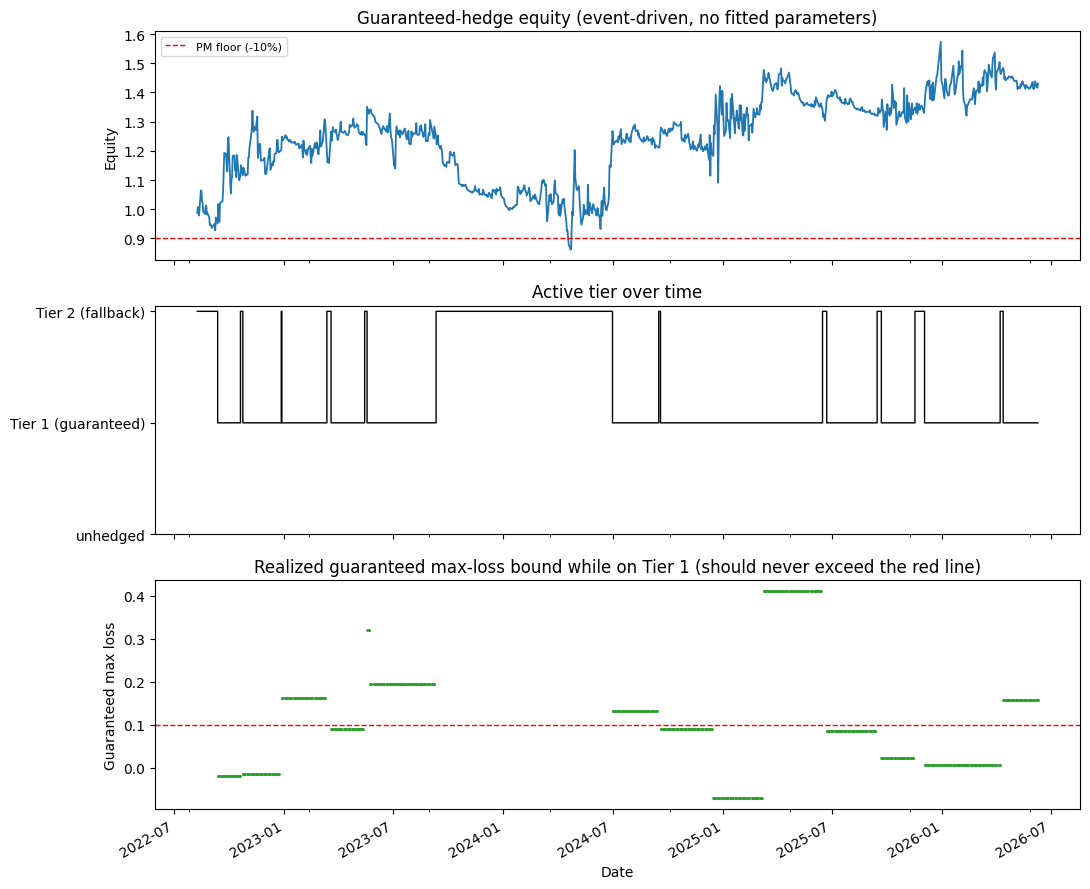

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

equity.plot(ax=axes[0], linewidth=1.3, color="tab:blue")
axes[0].axhline(1 - LOSS_TOLERANCE, color="red", linestyle="--", linewidth=1, label=f"PM floor (-{LOSS_TOLERANCE:.0%})")
axes[0].set_title("Guaranteed-hedge equity (event-driven, no fitted parameters)")
axes[0].set_ylabel("Equity")
axes[0].legend(fontsize=8)

tier_track.plot(ax=axes[1], linewidth=1.0, color="black", drawstyle="steps-post")
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(["unhedged", "Tier 1 (guaranteed)", "Tier 2 (fallback)"])
axes[1].set_title("Active tier over time")

guaranteed_bound.plot(ax=axes[2], linewidth=1.0, color="tab:green", marker=".", markersize=2, linestyle="none")
axes[2].axhline(LOSS_TOLERANCE, color="red", linestyle="--", linewidth=1)
axes[2].set_title("Realized guaranteed max-loss bound while on Tier 1 (should never exceed the red line)")
axes[2].set_ylabel("Guaranteed max loss")

fig.tight_layout()
plt.show()


## Risk metrics -- Sharpe, Max DD, CAGR, etc.

In [8]:
eq_returns = equity.pct_change().dropna()
risk = summarize(equity, eq_returns, "Guaranteed hedge (Tier 1 + Tier 2 fallback)")
pd.DataFrame([risk])


,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar
0,Guaranteed hedge (Tier 1 + Tier 2 fallback),0.097972,0.454191,0.435895,-0.362032,0.270617
